# `정규화 및 표준화(Normalization & Standardization`
> `각 변수가 가진 값의 범위(scale)가 크게 다를 경우 생기는 문제점` : <br> 모델은 스케일이 큰 변수의 영향을 더 많이 받게 되어 학습이 한쪽으로 치우치는 현상이 발생한다.<br>
> 
> `해결 방법` :　데이터 스케일링 = 각 변수의 값 범위를 비슷한 기준으로 맞추는 전처리 과정

<br><br>

## 📏 스케일링 기법
<br>

* **정규화(Nomalization**
> <code>데이터의 최솟값을 0으로, 최댓값을 1로 맞추어 모든 값을 0과 1사이의 비율로 나타낸다.<code><br>
> 
> 단점: 이상치(Outlier)에 매우 민감하다.
>
> 알고리즘이 데이터의 분포를 특정하게 가정하지 않을 때(EX. K-최근접 이웃), 데이터의 분포를 특정 범위로 압축하고 싶을 때(EX. 이미지 픽셀 값) 사용.

<br>

* **표준화(standardization)**
> "<code>  　전체 데이터 중 평균(mean)이 되는 값을 0 Z-score, 즉 기준점으로 맞춰두고,
> 　 　 　 　평균에서 1 표준편차만큼 떨어진 데이터를 1 Z-score 로 만든다. 　 　　</code>" 　 　 　 　===> 규칙
>
> 장점: 이상치에 상대적으로 덜 민감하여, 안정적임.
>
> 대부분의 머신러닝 알고리즘에서 가장 보편적임.<br> 특히, 데이터가 정규분포를 따른다고 가정하는 모델에서 효과적(EX. 선형 회귀, 로지스틱 회귀)

<details><summary><code>표준화 그림 보기<code></summary>

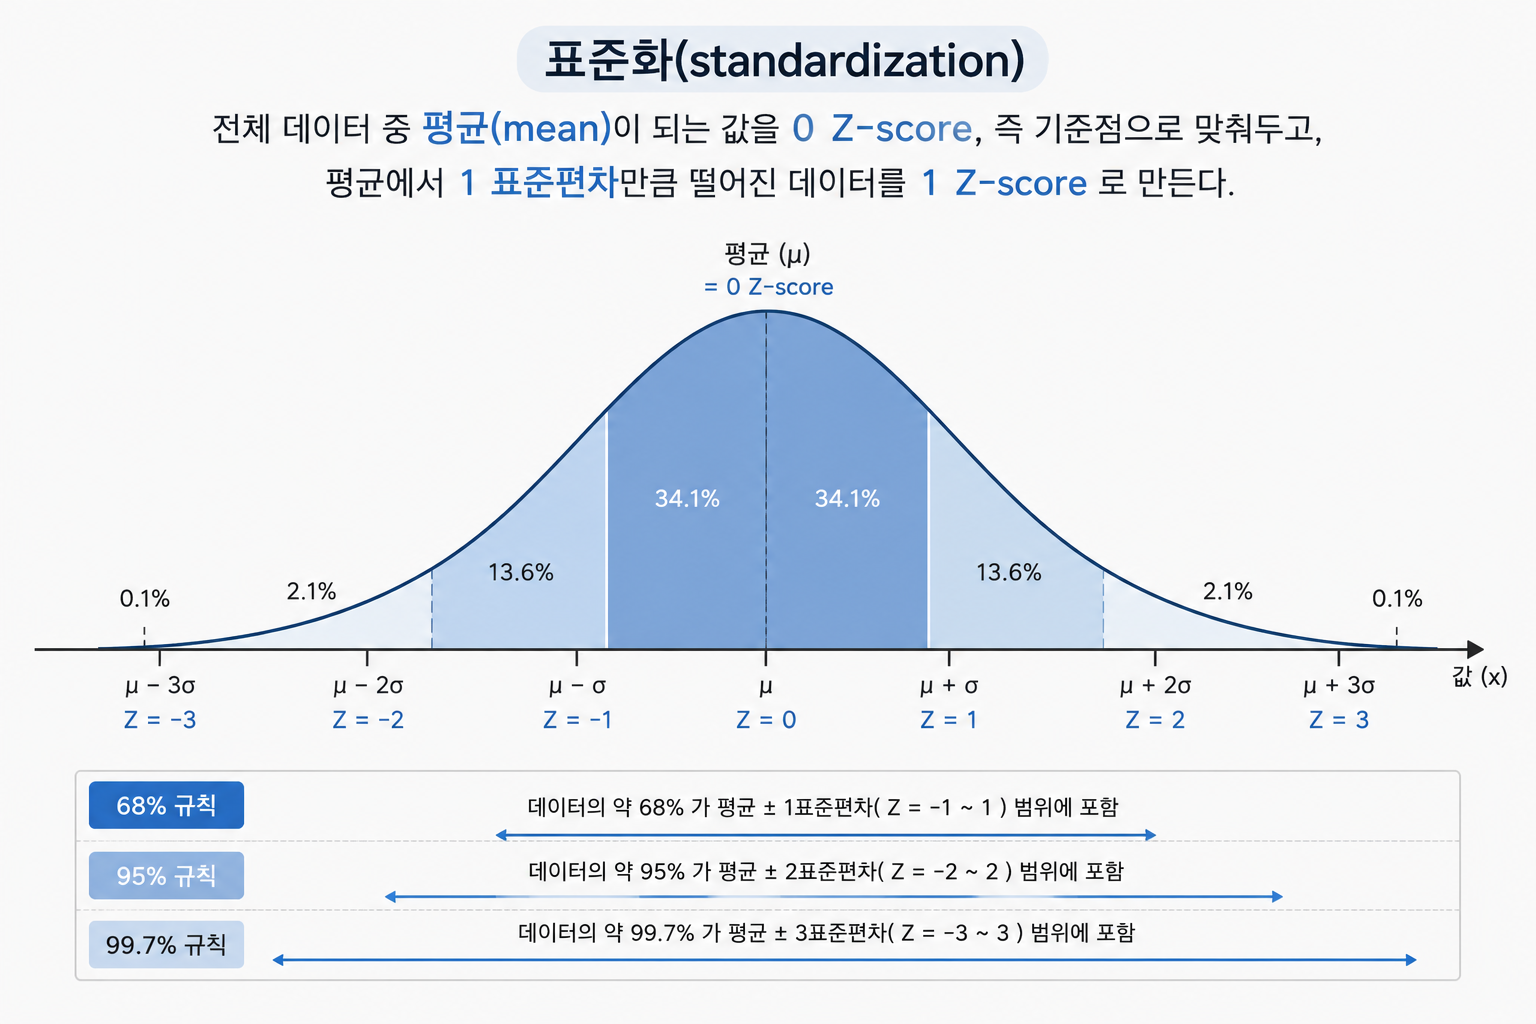 
</details>

<br><br><br><br><br>
## 🚩 1. 정규화 — MinMaxScaler<br>
> <b>개념</b>: 데이터의 최소값을 0, 최대값을 1로 변환하여 모든 데이터를 $[0, 1]$ 범위 안에 위치시킨다.<br>
> <b>사용 시점</b>: 이미지 처리 (픽셀값 0\~255를 0\~1로 변환), 　음수 값이 없어야 하는 특성 (예: 상품 가격, 신체 치수 등), 　<br>　　　　　혹은 데이터의 분포가 정규분포가 아니라는 것을 알고 있을 때 (예: 한쪽으로 치우친 데이터 등) 적합하다.

<br><br>
### 데이터 정규화 하기

In [5]:
# 데이터 핸들링을 위한 pandas와 Scikit-learn의 MinMaxScaler를 불러온다.
import pandas as pd
from sklearn.preprocessing import MinMaxScaler

# 실습을 위해 데이터를 다시 불러온다.
df = pd.read_csv("D:\[실습 파일] 이론 데이터셋\Part3 House Price.csv")

df.rename(columns={'GrLivArea':'LivingArea'}, inplace=True)

# MinMaxScaler 객체를 생성한다 (MinMaxScaler 불러와 스케일링 준비를 한다)
scaler = MinMaxScaler()

# 원본 'LivingArea' 컬럼의 상위 5개 값을 확인한다.
print("--- 정규화 전 데이터 ---")
print(df['LivingArea'].head())

# LivingArea 컬럼을 'fit_transform() 메서드에 적용(= MinMaxScaler 사용)'하여 정규화를 수행한다.
# fit_transform() : 데이터의 최솟값과 최댓값이 무엇인지 학습(fit)하고, 그 기준에 맞춰 데이터를 0과 1로 변환(transform)하는 작업을 동시에 수행한다.
df['LivingArea_MMS'] = scaler.fit_transform(df[['LivingArea']])
# fit_transform()은 2D 배열을 입력으로 기대하므로, 대괄호를 두 번 사용해 [[...]] 형태로 만들어 준다.

# 그 결과를 새로운 컬럼 LivinfArea_MMS에 저장하여 원본 데이터와 비교한다.
print("\n--- 정규화 후 데이터 ---")                              
print(df['LivingArea_MMS'].head())

--- 정규화 전 데이터 ---
0    1710
1    1262
2    1786
3    1717
4    2198
Name: LivingArea, dtype: int64

--- 정규화 후 데이터 ---
0    0.259231
1    0.174830
2    0.273549
3    0.260550
4    0.351168
Name: LivingArea_MMS, dtype: float64


<br><br><br><br>

### 데이터의 분포를 시각화하여 스케일링 효과 한눈에 보기

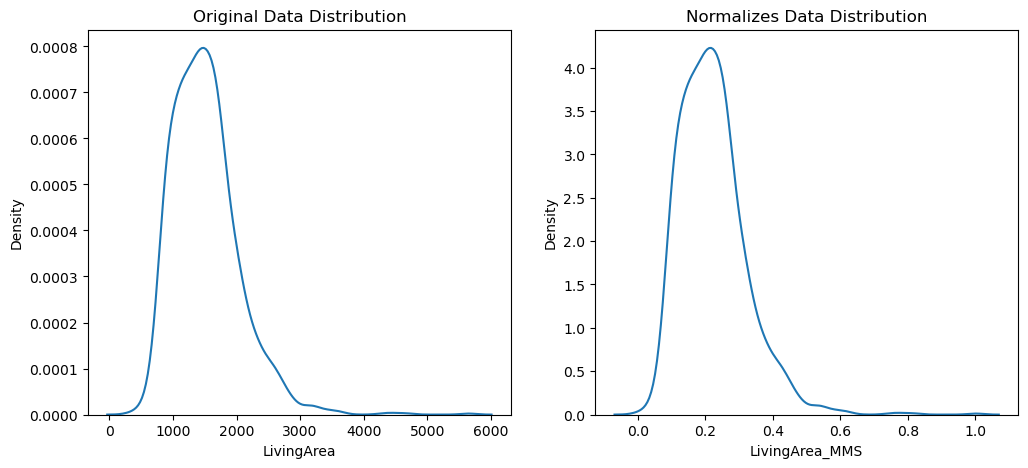

In [6]:
# 숫자로만 보면 스케일링의 효과가 와닿지 않을 수 있다.
# < 데이터의 분포를 시각화하여 비교해보자! >

# Seaborn의 kedplot(커널 밀도 추정)을 사용해 두 그래프를 비교해보자
# 스케일링 전과 후의 '모양'과 '척도(scale)' 변화를 비교해보자

# ================================================== 코드 ==================================================

# 1) 데이터 시각화를 위한 라이브러리를 불러온다.
import seaborn as sns
import matplotlib.pyplot as plt

# 2) 1행 2열의 그래프를 그릴 공간(fig)과 각 그래프가 그려질 축(axes)을 만든다.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
# plt.subplots()을 이용해 1행 2열의 그래프 공간을 만든다.

# 3) 첫 번째 그래프(axes[0])에 원본 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea'], ax=axes[0])
axes[0].set_title('Original Data Distribution')

# 4) 두 번째 그래프(axes[1])에 정규화된 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea_MMS'], ax=axes[1])
axes[1].set_title('Normalizes Data Distribution')

plt.show()

#### 📌 실행결과
1. `분포 '모양'은 거의 유사함`:<br>정규화가 데이터의 상대적 순서와 분포 형태를 크게 바꾸지 않으면서, 스케일만 조정한다는 의미
2. `x 축의 '척도(Scale)'가 크게 달라짐`:<br>원본 데이터는 0부터 6000에 가까운 넓은 범위인 반면, 정규화된 데이터는 <b>0과 1이라는 좁은 범위로 압축됨</b>
<br><br>

<br><br><br>
## 🚩 2. 표준화 — StandardScaler<br>
> <b>개념</b>: 전체 데이터 세트의 평균과 표준편차를 계산하여, 중심을 0으로 이동시키고 스케일을 표준편차 단위로 맞춘다.<br>
> <b>사용 시점</b>: 데이터가 대략적으로 정규분포를 따르거나, 경사하강법 기반 모델(신경망 등), 거리 기반 알고리즘(KNN, SVM), 차원 축소(PCA)를 사용할 때 가장 기본적인 표준 선택지이다.

<br><br>
### 데이터 표준화 하기

In [11]:
# 데이터 핸들링을 위한 pandas와 Scikit-learn의 StandardScaler를 불러온다.
import pandas as pd
from sklearn.preprocessing import StandardScaler

# 실습을 위해 데이터를 다시 불러온다.
df = pd.read_csv("D:\[실습 파일] 이론 데이터셋\Part3 House Price.csv")
df.rename(columns={'GrLivArea':'LivingArea'}, inplace=True)
# StandardScaler 객체를 생성한다.
scaler = StandardScaler()

# 원본 'LivingArea' 컬럼의 상위 5개 값을 확인한다.
print("--- 표준화 전 데이터 ---")
print(df['LivingArea'].head())

# StandardScaler를 사용해 'LivingArea' 컬럼을 표준화한다.
df['LivingArea_SS'] = scaler.fit_transform(df[['LivingArea']])

# 표준화 후 생성된 새로운 컬럼의 상위 5개 값을 확인한다.
print("\n--- 표준화 후 데이터 ---")
print(df['LivingArea_SS'].head())

--- 표준화 전 데이터 ---
0    1710
1    1262
2    1786
3    1717
4    2198
Name: LivingArea, dtype: int64

--- 표준화 후 데이터 ---
0    0.370333
1   -0.482512
2    0.515013
3    0.383659
4    1.299326
Name: LivingArea_SS, dtype: float64


<br><br><br>
## 🚩 3. RobustScaler (변형 표준화 / Robust Scaling)<br>
> `MinMaxScaler(정규화)`는 최솟값과 최댓값을 기준으로 변환하므로, 극단적인 이상치가 하나라도 있으면 나머지 정상 데이터들이 좁은 범위에 몰린다.<br>
> `StandardScaler(표준화)`는 평균과 표준편차를 사용하는데, 이상치가 평균과 표준편차를 왜곡시킬 수 있다.<br>
> &rarr; 　　<b>두 기법 모두 이상치(Outlier)의 영향을 받을 수 있는 약점</b>이 있다.
>
> <b>`RobustScaler: 이상치에 '강건한(Robust)' 스케일러다.`</b>
>
> 평균과 표준편차 대신 <b>`중앙값(Median, Q₂)과 사분위수 범위(IQR, Q₃ - Q₁)`를 사용</b>한다.<br>
>
>  
> <b>사용 시점</b>: 데이터에 이상치(Outlier)가 다수 존재하여 StandardScaler나 MinMaxScaler를 적용하면 성능이 왜곡되는 경우에 최선의 대안이 된다.

<br>

<div style="border: 1px solid #e0e0e0; background-color: #f8f9fa; padding: 15px; border-radius: 8px;">
    
## 📐 RobustScaler의 변환 공식

> 데이터의 왜곡을 최소화하기 위해 중앙값과 IQR을 활용하는 핵심 수식.<br>
> 중앙값과 IQR은 극단적인 이상치의 영향을 상대적으로 덜 받기 때문에, 변환 결과가 안정적이다.

<div style="background-color: #f8f9fa; border: 1px solid #ced4da; padding: 15px; border-radius: 6px; text-align: center; font-weight: bold;">
변환된 값 = (원래 값 - 중앙값) / IQR
</div>

* 중앙값(median) : 데이터를 크기 순서로 정렬했을 때 가운데 위치한 값
* IQR = Q3(75%) - Q1(25%)
</div>

<br><br>
### 데이터 스케일링하기

In [14]:
import pandas as pd
from sklearn.preprocessing import RobustScaler

# 데이터 불러오기 
df = pd.read_csv("D:\[실습 파일] 이론 데이터셋\Part3 House Price.csv")

df.rename(columns={'GrLivArea':'LivingArea'}, inplace=True)

# Robust Scaler 객체를 생성한다.
scaler = RobustScaler()

print("--- 스케일링 전 데이터 ---")
print(df['LivingArea'].head())

# RobustScaler를 사용해 'GrLivArea' 컬럼을 스케일링한다.
df['LivingArea_RS'] = scaler.fit_transform(df[['LivingArea']])

# 스케일링 후 생성된 새로운 컬럼의 상위 5개 값을 확인한다.
print("\n --- 스케일링 후 데이터 ---")
print(df[['LivingArea', 'LivingArea_RS']].head())

--- 스케일링 전 데이터 ---
0    1710
1    1262
2    1786
3    1717
4    2198
Name: LivingArea, dtype: int64

 --- 스케일링 후 데이터 ---
   LivingArea  LivingArea_RS
0        1710       0.380070
1        1262      -0.312090
2        1786       0.497489
3        1717       0.390885
4        2198       1.134029


<br>

#### 📌 실행결과
중앙값(median)에 해당되는 데이터는 정확히 0으로 변환된다.<br>
실행 결과를 보면, RobustScaler로 변환된 값들은 0(=중앙값)을 중심으로 분포한다. 　 &rarr; 　<b>`이상치가 있는 데이터에서는 중앙값을 기준점(0)으로 두는 것이 안정적이다.`</b>
<br><br><br><br>

<br><br>
## 데이터 시각화 하기
> 네 가지 데이터 (원본, 정규화, 표준화, 로버스트 스케일링)의 분포를 나란히 놓고 <br>
> 각 스케일링 기법이 데이터에 어떤 영향을 미치는지 비교해보자.

<function matplotlib.pyplot.show(close=None, block=None)>

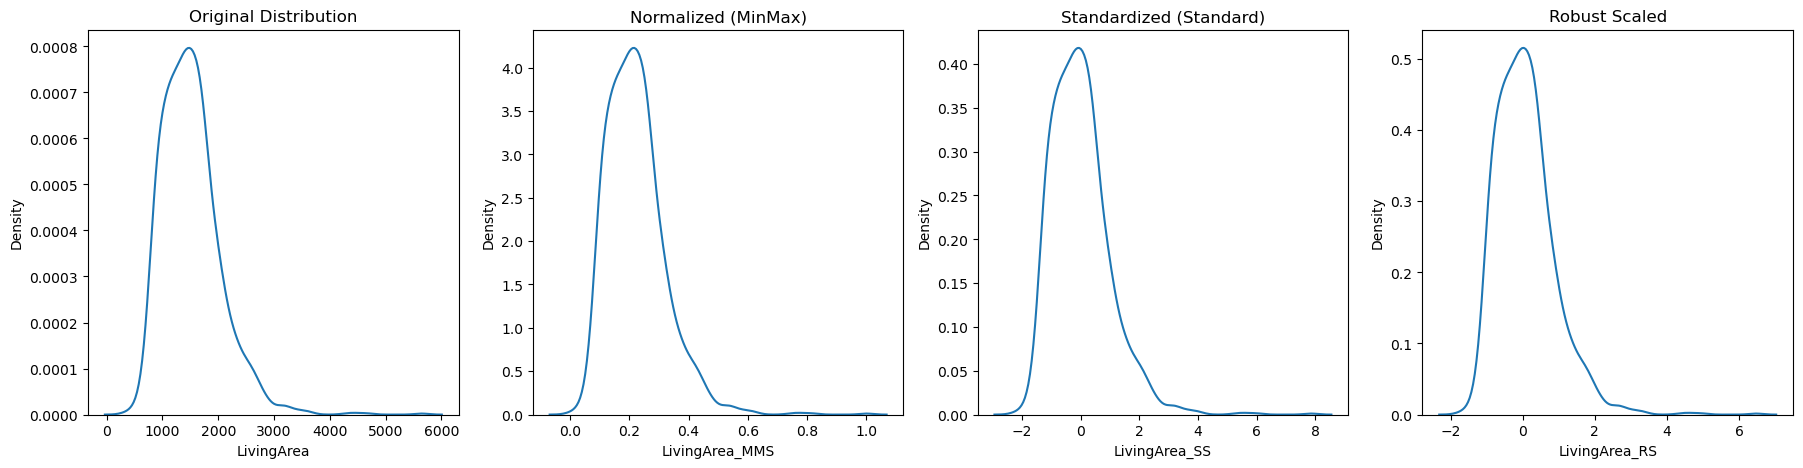

In [16]:
# ----------- <도구 불러오기> -----------
# 데이터 시각화를 위한 라이브러리를 불러온다.
import seaborn as sns
import matplotlib.pyplot as plt

# 스케일러를 모두 불러온다.
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler


# ----------- <데이터 불러오기 및 컬럼명 변경> -----------
df = pd.read_csv("D:\[실습 파일] 이론 데이터셋\Part3 House Price.csv")
# GrLivArea 컬럼명을 LivingArea로 변경
df.rename(columns={'GrLivArea':'LivingArea'}, inplace=True)


# ----------- <스케일링> -----------
# 스케일링 객체 생성 
norm_scaler = MinMaxScaler()
std_scaler = StandardScaler()
robust_scaler = RobustScaler()

# 스케일링 하기
df['LivingArea_MMS']= norm_scaler.fit_transform(df[['LivingArea']])
df['LivingArea_SS'] = std_scaler.fit_transform(df[['LivingArea']])
df['LivingArea_RS'] = robust_scaler.fit_transform(df[['LivingArea']])

# ----------- <시각화하기> -----------
# 1행 4열의 그래프를 그릴 공간(fig)과 각 그래프가 그려질 축(axes)를 만든다.
fig, axes = plt.subplots(1, 4, figsize=(22, 5))

# 첫 번째 그래프(axes[0])에 원본 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea'], ax=axes[0])
axes[0].set_title('Original Distribution')

# 두 번째 그래프(axes[1])에 정규화된 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea_MMS'], ax=axes[1])
axes[1].set_title('Normalized (MinMax)')

# 세 번째 그래프(axes[2])에 표준화된 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea_SS'], ax=axes[2])
axes[2].set_title('Standardized (Standard)')

# 네 번째 그래프(axes[3])에 로버스팅 스케일링된 데이터의 분포를 그린다.
sns.kdeplot(df['LivingArea_RS'], ax=axes[3])
axes[3].set_title('Robust Scaled')

plt.show

<br>

#### 📌 실행결과
네 가지 분포의 '모양'이 크게 변하지 않는다.<br>
&rarr; 　 scaling 작업이 **데이터의 상대적 분포 형태를크게 바꾸지 않고, 오직 값의 척도(scale)만 변경한다**는 것을 보여준다.<br><br>

원본: x축의 넓은 범위에 퍼져있다<br>
정규화: 0과 1사이에 압축되어 있다<br>
표준화: 평균(mean)을 0으로 하여 중심으로 자리잡고 있다<br>
로버스트: 중앙값(median, Q2)을 0으로 하여 중심으로 자리잡고 있다
<br><br>

<br><br><br><br><br><br>

#### 📌 Scaler 선택 알고리즘<br>
데이터가 텍스트/희소 행렬(Sparse Matrix)인가?<br>$\rightarrow$ MaxAbsScaler (특성별 스케일링 필요 시) 또는 Normalizer (샘플 벡터별 스케일링 필요 시)<br><br>이상치(Outlier)의 영향이 매우 강하고 수동 제거가 어려운가?<br>$\rightarrow$ RobustScaler<br><br>데이터가 일정한 범위([0, 1] 등)에 엄격히 제한되어야 하는가? (예: 이미지, 픽셀)<br>$\rightarrow$ MinMaxScaler<br><br>일반적인 연산 알고리즘(SVM, 선형 모델, 신경망, PCA)을 사용하는가?<br>$\rightarrow$ StandardScaler (가장 무난하고 안정적인 Default 선택)<br><br><br><br>
(아직 안 배운거 있지만 Gemini 답변이라서 넣음. **참고로 보기**)